# FakeLens 360 — Audit avancé et baselines sur LIAR

Ce notebook prolonge l'exploration initiale avec une démarche plus scientifique :

1. audit de qualité et recherche de fuites ;
2. analyse des doublons, locuteurs et métadonnées ;
3. baseline forte `TF-IDF mots + caractères + LinearSVC` ;
4. modèle hybride `texte + métadonnées` ;
5. analyse des erreurs et de l'incertitude ;
6. création d'une version harmonisée pour la comparaison multi-datasets.

> Le notebook original est conservé. Celui-ci constitue la suite du travail.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import json
import re
import unicodedata
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Configuration robuste des chemins

Modifie uniquement `PROJECT_ROOT` si ton dossier Google Drive porte un autre nom.

In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/FakeNewsDetection")
DATA_DIR = PROJECT_ROOT / "data" / "liar"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

required_files = [DATA_DIR / "train.tsv", DATA_DIR / "valid.tsv", DATA_DIR / "test.tsv"]
missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Fichiers LIAR introuvables. Vérifie PROJECT_ROOT.\n" + "\n".join(missing_files)
    )

print("Dossier projet :", PROJECT_ROOT)

Dossier projet : /content/drive/MyDrive/FakeNewsDetection


## 2. Chargement du dataset LIAR

In [4]:
COLUMNS = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context",
]

def load_liar_split(path: Path, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None, names=COLUMNS)
    df["split"] = split_name
    return df

train = load_liar_split(DATA_DIR / "train.tsv", "train")
valid = load_liar_split(DATA_DIR / "valid.tsv", "valid")
test = load_liar_split(DATA_DIR / "test.tsv", "test")

splits = {"train": train, "valid": valid, "test": test}

pd.DataFrame({
    "split": list(splits.keys()),
    "lignes": [len(df) for df in splits.values()],
    "colonnes": [df.shape[1] for df in splits.values()],
})

,split,lignes,colonnes
0,train,10240,15
1,valid,1284,15
2,test,1267,15


## 3. Audit de qualité

On vérifie les valeurs manquantes, textes vides, doublons exacts et chevauchements entre les ensembles.

In [5]:
def normalize_for_audit(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

for df in splits.values():
    df["statement"] = df["statement"].fillna("").astype(str)
    df["text_norm"] = df["statement"].map(normalize_for_audit)
    df["n_chars"] = df["statement"].str.len()
    df["n_words"] = df["statement"].str.split().str.len()

audit_rows = []
for split_name, df in splits.items():
    audit_rows.append({
        "split": split_name,
        "lignes": len(df),
        "textes_vides": int(df["text_norm"].eq("").sum()),
        "doublons_texte": int(df.duplicated("text_norm").sum()),
        "doublons_id": int(df.duplicated("id").sum()),
        "mots_moyens": round(df["n_words"].mean(), 2),
        "caracteres_moyens": round(df["n_chars"].mean(), 2),
    })

audit_table = pd.DataFrame(audit_rows)
audit_table

,split,lignes,textes_vides,doublons_texte,doublons_id,mots_moyens,caracteres_moyens
0,train,10240,0,17,0,18.01,106.92
1,valid,1284,0,0,0,17.93,106.71
2,test,1267,0,0,0,18.40,109.58


In [6]:
def overlap_count(df_a: pd.DataFrame, df_b: pd.DataFrame, column: str) -> int:
    a = set(df_a[column].dropna().astype(str))
    b = set(df_b[column].dropna().astype(str))
    return len(a & b)

overlap_table = pd.DataFrame([
    {
        "comparaison": "train ↔ valid",
        "textes_communs": overlap_count(train, valid, "text_norm"),
        "locuteurs_communs": overlap_count(train, valid, "speaker"),
    },
    {
        "comparaison": "train ↔ test",
        "textes_communs": overlap_count(train, test, "text_norm"),
        "locuteurs_communs": overlap_count(train, test, "speaker"),
    },
    {
        "comparaison": "valid ↔ test",
        "textes_communs": overlap_count(valid, test, "text_norm"),
        "locuteurs_communs": overlap_count(valid, test, "speaker"),
    },
])

overlap_table

,comparaison,textes_communs,locuteurs_communs
0,train ↔ valid,5,446
1,train ↔ test,4,443
2,valid ↔ test,0,228


### Pourquoi cette étape est importante

Un même texte dans l'entraînement et le test peut gonfler artificiellement les résultats.  
Le chevauchement des locuteurs peut également permettre au modèle d'apprendre le profil d'une personne au lieu de vérifier réellement l'affirmation.

In [7]:
missing_percent = (
    train[COLUMNS]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percent.to_frame("pourcentage_manquant")

,pourcentage_manquant
speaker_job,28.300781
state_info,21.582031
context,0.996094
barely_true_counts,0.019531
speaker,0.019531
subject,0.019531
false_counts,0.019531
half_true_counts,0.019531
mostly_true_counts,0.019531
party_affiliation,0.019531


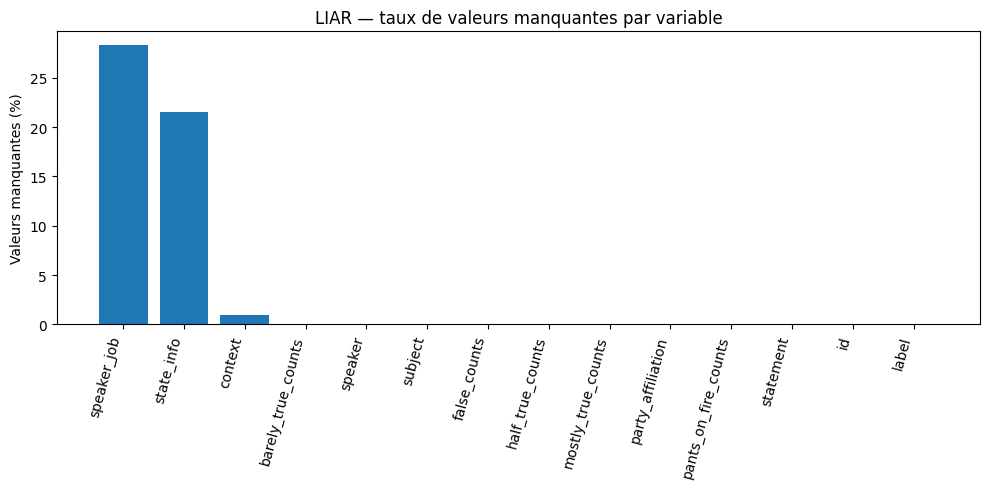

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(missing_percent.index, missing_percent.values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Valeurs manquantes (%)")
plt.title("LIAR — taux de valeurs manquantes par variable")
plt.tight_layout()
plt.show()

## 4. Analyse des classes et des longueurs

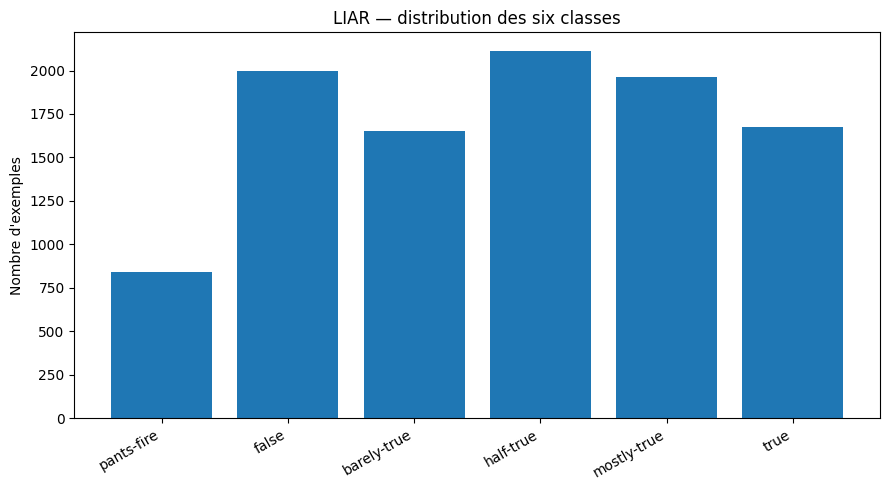

In [9]:
label_order = [
    "pants-fire",
    "false",
    "barely-true",
    "half-true",
    "mostly-true",
    "true",
]

label_counts = train["label"].value_counts().reindex(label_order)

plt.figure(figsize=(9, 5))
plt.bar(label_counts.index, label_counts.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Nombre d'exemples")
plt.title("LIAR — distribution des six classes")
plt.tight_layout()
plt.show()

In [10]:
length_by_label = (
    train.groupby("label")["n_words"]
    .agg(["count", "mean", "median", "std", "max"])
    .reindex(label_order)
    .round(2)
)

length_by_label

,count,mean,median,std,max
label,,,,,
pants-fire,839,17.13,16.0,7.49,49
false,1995,16.99,15.0,10.15,309
barely-true,1654,18.16,17.0,7.80,57
half-true,2114,18.79,18.0,8.05,60
mostly-true,1962,18.45,17.0,12.73,467
true,1676,18.02,16.0,9.24,235


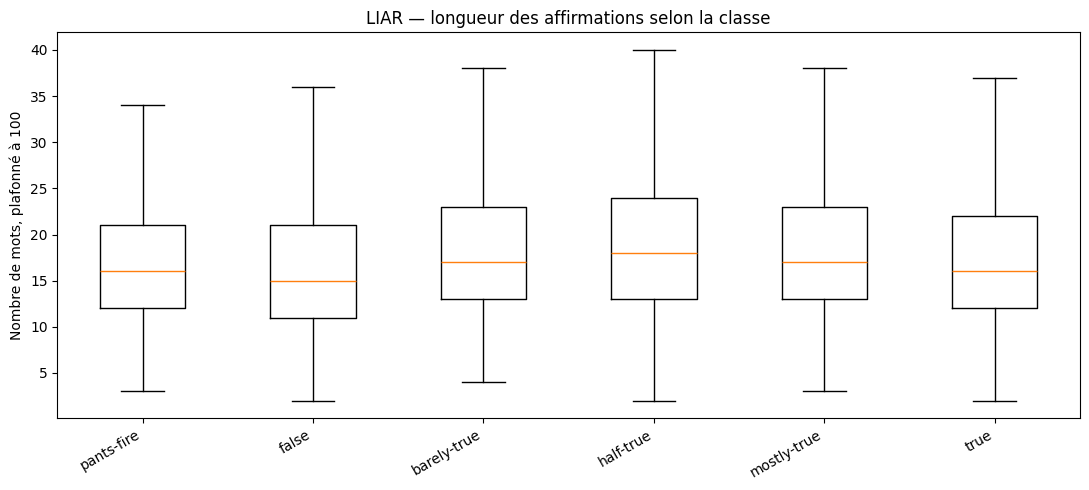

In [11]:
data_to_plot = [
    train.loc[train["label"] == label, "n_words"].clip(upper=100)
    for label in label_order
]

plt.figure(figsize=(11, 5))
plt.boxplot(data_to_plot, labels=label_order, showfliers=False)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Nombre de mots, plafonné à 100")
plt.title("LIAR — longueur des affirmations selon la classe")
plt.tight_layout()
plt.show()

## 5. Analyse contextuelle : sujets, partis et locuteurs

In [12]:
def top_values(df: pd.DataFrame, column: str, n: int = 15) -> pd.DataFrame:
    return (
        df[column]
        .fillna("INCONNU")
        .value_counts()
        .head(n)
        .rename_axis(column)
        .reset_index(name="effectif")
    )

display(top_values(train, "speaker"))
display(top_values(train, "subject"))
display(top_values(train, "party_affiliation"))

,speaker,effectif
0,barack-obama,488
1,donald-trump,273
2,hillary-clinton,239
3,mitt-romney,176
4,scott-walker,149
5,john-mccain,148
6,rick-perry,142
7,chain-email,142
8,marco-rubio,117
9,rick-scott,115


,subject,effectif
0,health-care,381
1,taxes,308
2,immigration,253
3,elections,252
4,education,237
5,candidates-biography,190
6,economy,137
7,guns,130
8,"economy,jobs",125
9,federal-budget,121


,party_affiliation,effectif
0,republican,4497
1,democrat,3336
2,none,1744
3,organization,219
4,independent,147
5,newsmaker,56
6,libertarian,40
7,activist,39
8,journalist,38
9,columnist,35


## 6. Baseline forte : mots + caractères

La combinaison de n-grammes de mots et de caractères est robuste aux variantes orthographiques, noms propres et formulations courtes.

In [13]:
word_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=50000,
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    lowercase=True,
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
    max_features=50000,
)

text_features = FeatureUnion([
    ("word_tfidf", word_vectorizer),
    ("char_tfidf", char_vectorizer),
])

text_model = Pipeline([
    ("features", text_features),
    ("classifier", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
])

text_model.fit(train["statement"], train["label"])

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('word_tfidf',
                                                 TfidfVectorizer(max_df=0.98,
                                                                 max_features=50000,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              2),
                                                                 strip_accents='unicode',
                                                                 sublinear_tf=True)),
                                                ('char_tfidf',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_features=50000,
                                                                 min_df=2,
                                                                 ngram_range=(3,
                                                                              5),
                                                                 sublinear_tf=True))])),
                ('classifier',
                 LinearSVC(class_weight='balanced', random_state=42))])

In [14]:
def evaluate_predictions(y_true, y_pred, model_name: str):
    result = {
        "modele": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    }
    print(pd.Series(result))
    print("\nRapport détaillé :\n")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    return result

valid_pred_text = text_model.predict(valid["statement"])
test_pred_text = text_model.predict(test["statement"])

results = []
results.append(evaluate_predictions(valid["label"], valid_pred_text, "TF-IDF mots+caractères / validation"))
results.append(evaluate_predictions(test["label"], test_pred_text, "TF-IDF mots+caractères / test"))

modele         TF-IDF mots+caractères / validation
accuracy                                  0.254673
f1_macro                                  0.255006
f1_weighted                               0.254174
dtype: object

Rapport détaillé :

              precision    recall  f1-score   support

 barely-true     0.2166    0.1983    0.2070       237
       false     0.2720    0.2700    0.2710       263
   half-true     0.2570    0.2581    0.2575       248
 mostly-true     0.2708    0.2590    0.2648       251
  pants-fire     0.2632    0.2586    0.2609       116
        true     0.2463    0.2959    0.2688       169

    accuracy                         0.2547      1284
   macro avg     0.2543    0.2566    0.2550      1284
weighted avg     0.2545    0.2547    0.2542      1284

modele         TF-IDF mots+caractères / test
accuracy                            0.250987
f1_macro                            0.243448
f1_weighted                         0.250611
dtype: object

Rapport détaillé :

   

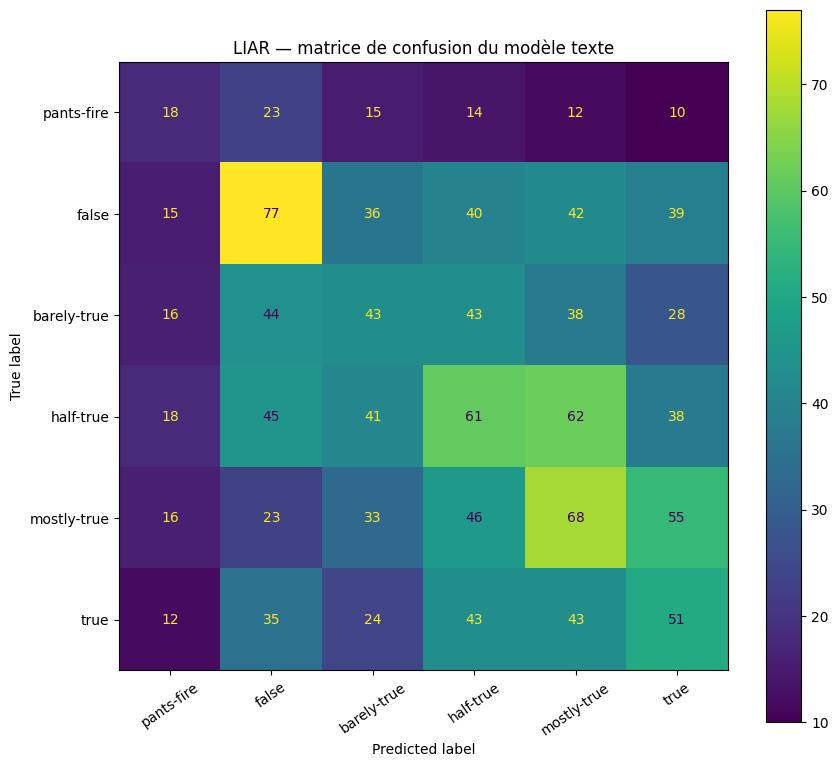

In [15]:
cm = confusion_matrix(test["label"], test_pred_text, labels=label_order)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=label_order).plot(
    ax=ax,
    xticks_rotation=35,
    values_format="d",
)
plt.title("LIAR — matrice de confusion du modèle texte")
plt.tight_layout()
plt.show()

## 7. Modèle hybride : texte + métadonnées

Cette expérience mesure ce que les informations contextuelles ajoutent réellement au texte.  
Elle doit être présentée comme une **étude d'ablation** : texte seul contre texte + métadonnées.

In [16]:
categorical_columns = [
    "subject",
    "speaker",
    "speaker_job",
    "state_info",
    "party_affiliation",
    "context",
]

numeric_columns = [
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5)),
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler(with_mean=False)),
])

hybrid_features = ColumnTransformer([
    (
        "text_word",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True,
            max_features=50000,
        ),
        "statement",
    ),
    (
        "text_char",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
            max_features=50000,
        ),
        "statement",
    ),
    ("categorical", categorical_pipeline, categorical_columns),
    ("numeric", numeric_pipeline, numeric_columns),
])

hybrid_model = Pipeline([
    ("features", hybrid_features),
    (
        "classifier",
        SGDClassifier(
            loss="log_loss",
            class_weight="balanced",
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=5,
            random_state=RANDOM_STATE,
        ),
    ),
])

hybrid_model.fit(train, train["label"])

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('text_word',
                                                  TfidfVectorizer(max_df=0.98,
                                                                  max_features=50000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  sublinear_tf=True),
                                                  'statement'),
                                                 ('text_char',
                                                  TfidfVectorizer(analyzer='char_wb',
                                                                  max_features=50000,
                                                                  min_df=2,
                                                                  ngram_range=(3,
                                                                               5),
                                                                  sublinear_tf=True),
                                                  'statement'),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   Sim...
                                                   'context']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['barely_true_counts',
                                                   'false_counts',
                                                   'half_true_counts',
                                                   'mostly_true_counts',
                                                   'pants_on_fire_counts'])])),
                ('classifier',
                 SGDClassifier(class_weight='balanced', early_stopping=True,
                               loss='log_loss', max_iter=2000,
                               random_state=42))])

In [17]:
valid_pred_hybrid = hybrid_model.predict(valid)
test_pred_hybrid = hybrid_model.predict(test)

results.append(evaluate_predictions(valid["label"], valid_pred_hybrid, "Hybride texte+métadonnées / validation"))
results.append(evaluate_predictions(test["label"], test_pred_hybrid, "Hybride texte+métadonnées / test"))

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df

modele         Hybride texte+métadonnées / validation
accuracy                                     0.299844
f1_macro                                     0.302894
f1_weighted                                  0.297433
dtype: object

Rapport détaillé :

              precision    recall  f1-score   support

 barely-true     0.3000    0.2025    0.2418       237
       false     0.3487    0.2586    0.2969       263
   half-true     0.2924    0.3548    0.3206       248
 mostly-true     0.2866    0.3665    0.3217       251
  pants-fire     0.3983    0.4052    0.4017       116
        true     0.2222    0.2485    0.2346       169

    accuracy                         0.2998      1284
   macro avg     0.3080    0.3060    0.3029      1284
weighted avg     0.3045    0.2998    0.2974      1284

modele         Hybride texte+métadonnées / test
accuracy                               0.272297
f1_macro                               0.271177
f1_weighted                             0.26929
dtype: object


,modele,accuracy,f1_macro,f1_weighted
2,Hybride texte+métadonnées / validation,0.299844,0.302894,0.297433
3,Hybride texte+métadonnées / test,0.272297,0.271177,0.269290
0,TF-IDF mots+caractères / validation,0.254673,0.255006,0.254174
1,TF-IDF mots+caractères / test,0.250987,0.243448,0.250611


In [18]:
results_df.to_csv(RESULTS_DIR / "liar_model_comparison.csv", index=False)
joblib.dump(text_model, MODELS_DIR / "liar_text_linearsvc.joblib")
joblib.dump(hybrid_model, MODELS_DIR / "liar_hybrid_sgd_logloss.joblib")

print("Résultats sauvegardés dans :", RESULTS_DIR)
print("Modèles sauvegardés dans :", MODELS_DIR)

Résultats sauvegardés dans : /content/drive/MyDrive/FakeNewsDetection/results
Modèles sauvegardés dans : /content/drive/MyDrive/FakeNewsDetection/models


## 8. Analyse de l'incertitude et système d'abstention

Un système responsable ne doit pas toujours forcer une décision.  
On mesure ici la performance lorsque le modèle ne conserve que les prédictions suffisamment confiantes.

In [19]:
test_proba = hybrid_model.predict_proba(test)
test_confidence = test_proba.max(axis=1)
test_pred_probability = hybrid_model.classes_[test_proba.argmax(axis=1)]

abstention_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    mask = test_confidence >= threshold
    if mask.sum() == 0:
        continue

    abstention_rows.append({
        "seuil_confiance": threshold,
        "couverture": mask.mean(),
        "nombre_predictions": int(mask.sum()),
        "accuracy_sur_predictions": accuracy_score(
            test.loc[mask, "label"],
            test_pred_probability[mask],
        ),
        "f1_macro_sur_predictions": f1_score(
            test.loc[mask, "label"],
            test_pred_probability[mask],
            average="macro",
            zero_division=0,
        ),
    })

abstention_df = pd.DataFrame(abstention_rows)
abstention_df

,seuil_confiance,couverture,nombre_predictions,accuracy_sur_predictions,f1_macro_sur_predictions
0,0.3,0.872139,1105,0.285068,0.286754
1,0.4,0.544594,690,0.314493,0.320114
2,0.5,0.243094,308,0.347403,0.353657
3,0.6,0.099448,126,0.365079,0.357343
4,0.7,0.041042,52,0.442308,0.404244
5,0.8,0.014996,19,0.526316,0.295815


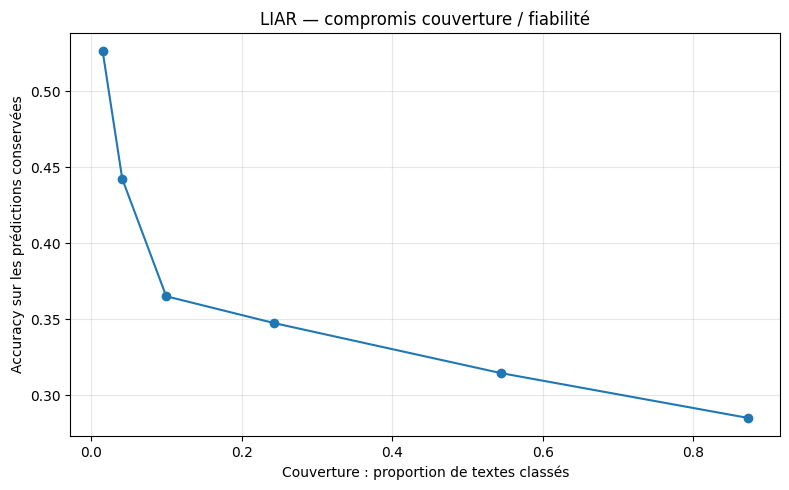

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(abstention_df["couverture"], abstention_df["accuracy_sur_predictions"], marker="o")
plt.xlabel("Couverture : proportion de textes classés")
plt.ylabel("Accuracy sur les prédictions conservées")
plt.title("LIAR — compromis couverture / fiabilité")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Analyse automatique des erreurs

In [21]:
error_table = test[
    test_pred_probability != test["label"].to_numpy()
][[
    "statement",
    "label",
    "speaker",
    "party_affiliation",
    "subject",
]].copy()

error_mask = test_pred_probability != test["label"].to_numpy()
error_table["prediction"] = test_pred_probability[error_mask]
error_table["confiance"] = test_confidence[error_mask]
error_table = error_table.sort_values("confiance", ascending=False)

error_table.head(25)

,statement,label,speaker,party_affiliation,subject,prediction,confiance
1255,There is no system to vet refugees from the Mi...,false,donald-trump,republican,"immigration,terrorism",pants-fire,0.918930
771,Says a Barack Obama black imposter joke got a ...,barely-true,chain-email,none,polls,pants-fire,0.908422
294,If the Trans-Pacific Partnership is fast-track...,false,chain-email,none,"congressional-rules,trade",pants-fire,0.892273
864,Says Barack Obama is the first president in mo...,mostly-true,donald-trump,republican,economy,false,0.875552
1262,Says his budget provides the highest state fun...,half-true,rick-scott,republican,education,mostly-true,0.849200
612,"Obama has ""visited more countries and met with...",true,chain-email,none,foreign-policy,pants-fire,0.834980
893,"Chinese tire imports threatened 1,000 American...",mostly-true,barack-obama,democrat,"china,message-machine-2012,trade",half-true,0.807296
833,Her campaign and her supporters in her campaig...,half-true,reince-priebus,republican,obama-birth-certificate,false,0.804864
1027,Barack Obama has doubled our national debt. Do...,half-true,donald-trump,republican,"debt,economy",false,0.804504
940,A few months ago when you were asked whats the...,half-true,barack-obama,democrat,"corrections-and-updates,debates,foreign-policy",mostly-true,0.799142


In [22]:
confusion_pairs = (
    pd.DataFrame({
        "vrai": test["label"],
        "predit": test_pred_probability,
    })
    .query("vrai != predit")
    .value_counts()
    .rename("effectif")
    .reset_index()
)

confusion_pairs.head(15)

,vrai,predit,effectif
0,half-true,mostly-true,64
1,mostly-true,half-true,62
2,true,mostly-true,53
3,barely-true,half-true,50
4,barely-true,mostly-true,49
5,false,mostly-true,47
6,true,half-true,45
7,false,half-true,41
8,false,true,40
9,half-true,true,39


## 10. Test plus réaliste : séparation par locuteur

Le modèle est évalué sur des locuteurs jamais vus pendant l'entraînement.  
Cette expérience est souvent plus difficile, mais elle donne une mesure plus crédible de généralisation.

In [23]:
group_data = train.dropna(subset=["speaker"]).copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

group_train_idx, group_test_idx = next(
    splitter.split(
        group_data["statement"],
        group_data["label"],
        groups=group_data["speaker"],
    )
)

speaker_train = group_data.iloc[group_train_idx]
speaker_test = group_data.iloc[group_test_idx]

speaker_model = clone(text_model)
speaker_model.fit(speaker_train["statement"], speaker_train["label"])
speaker_pred = speaker_model.predict(speaker_test["statement"])

speaker_result = evaluate_predictions(
    speaker_test["label"],
    speaker_pred,
    "TF-IDF — locuteurs jamais vus",
)
speaker_result

modele         TF-IDF — locuteurs jamais vus
accuracy                            0.223009
f1_macro                            0.224107
f1_weighted                         0.222668
dtype: object

Rapport détaillé :

              precision    recall  f1-score   support

 barely-true     0.1893    0.1776    0.1833       259
       false     0.2036    0.2006    0.2021       334
   half-true     0.2329    0.2429    0.2378       350
 mostly-true     0.2364    0.2335    0.2349       334
  pants-fire     0.2432    0.2571    0.2500       140
        true     0.2357    0.2374    0.2366       278

    accuracy                         0.2230      1695
   macro avg     0.2235    0.2249    0.2241      1695
weighted avg     0.2225    0.2230    0.2227      1695



{'modele': 'TF-IDF — locuteurs jamais vus',
 'accuracy': 0.22300884955752212,
 'f1_macro': 0.22410661378842744,
 'f1_weighted': 0.22266756229376325}

## 11. Harmonisation pour la comparaison avec FakeNewsNet et ArFakeD

Les six classes de LIAR n'ont pas le même niveau de granularité que les datasets binaires.  
Pour une comparaison honnête :

- `pants-fire`, `false`, `barely-true` → `FAKE`
- `mostly-true`, `true` → `REAL`
- `half-true` → `UNCERTAIN`

Pour un benchmark binaire, la classe `UNCERTAIN` est exclue plutôt que forcée artificiellement.

In [24]:
THREE_CLASS_MAP = {
    "pants-fire": "FAKE",
    "false": "FAKE",
    "barely-true": "FAKE",
    "half-true": "UNCERTAIN",
    "mostly-true": "REAL",
    "true": "REAL",
}

processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

for split_name, df in splits.items():
    standardized = pd.DataFrame({
        "text": df["statement"],
        "label_original": df["label"],
        "label_3class": df["label"].map(THREE_CLASS_MAP),
        "dataset": "LIAR",
        "language": "en",
        "split": split_name,
        "speaker": df["speaker"],
        "subject": df["subject"],
    })

    standardized["label_binary"] = standardized["label_3class"].where(
        standardized["label_3class"].isin(["FAKE", "REAL"])
    )

    standardized.to_csv(
        processed_dir / f"liar_{split_name}_standardized.csv",
        index=False,
    )

print("Fichiers harmonisés enregistrés dans :", processed_dir)

Fichiers harmonisés enregistrés dans : /content/drive/MyDrive/FakeNewsDetection/data/processed


## 12. Conclusions à intégrer dans le rapport

À compléter après exécution :

- qualité et limites du dataset ;
- présence éventuelle de doublons ou chevauchements ;
- performance du modèle texte seul ;
- gain ou perte du modèle hybride ;
- principales confusions entre classes voisines ;
- baisse de performance lorsque les locuteurs du test sont inconnus ;
- intérêt du mécanisme d'abstention pour un usage responsable.